# Tutorial 210: Conditional Flow Matching — PBMC 

Tutorial 200 showed conditional FM on synthetic two-moons data with a 3-dim one-hot condition. Here we scale to real PBMC data


* **Source**: PBS-treated cells of each cell type
* **Target**: Cytokine-treated cells of the same cell type

In [36]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Contents

* **Section 1**: Load and Explore Data
* **Section 2**: PCA Preprocessing
* **Section 3**: SCFlow Register Setup
* **Section 4**: Exploring the Grouped Data Tree
* **Section 5**: Model Setup
* **Section 6**: Training
* **Section 7**: Saving & Loading Model
* **Section 8**: Testing
* **Section 9**: ODE Trajectories

In [37]:
import anndata as ad
import numpy as np
import pandas as pd
import torch
import scanpy as sc
import matplotlib.pyplot as plt

from sc_flow import SCFlow
from sc_flow.preprocessing import PCATransform

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

## Section 1: Load and Explore Data

The dataset contains 10,000 PBMC cells profiled across 2,000 highly variable genes.
> Have to run all of thi with the complete dataset later
- `obs['treatment']`: `'PBS'` (source, 563 cells) or `'cytokine'` (9437 cells)
- `obs['cytokine']`: one of 91 unique values including `'PBS'`
- `obs['cell_type']`: cell type annotation — used as the grouping variable
- `uns['esm2_embeddings']`: dict mapping cytokine name → 2560-dim ESM2 vector

Because we will group by `cell_type`, we need every outer group to contain PBS source cells.
We filter `adata` to only cell types that appear in the PBS population before registering.

In [ ]:
DATA_PATH = r"C:\Users\HP\Documents\munich_work\CellFlow\pbmc_small.h5ad"
adata = sc.read_h5ad(DATA_PATH)
print(adata)

AnnData object with n_obs × n_vars = 10000 × 2000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'cytokine_family'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'donor_embeddings', 'esm2_embeddings', 'hvg', 'log1p'

Usable cytokines: 90
PBS source cells: 563


In [56]:
cytokines_with_cells = set(adata.obs["cytokine"].unique()) - {"PBS"}
cytokines_with_esm2 = set(adata.uns["esm2_embeddings"].keys())
usable_cytokines = sorted(cytokines_with_cells & cytokines_with_esm2)
print(f"\nUsable cytokines: {len(usable_cytokines)}")
print(f"PBS source cells: {(adata.obs['treatment'] == 'PBS').sum()}")


Usable cytokines: 90
PBS source cells: 563


In [39]:
# Grouping by cell_type requires every outer group to have PBS source cells.
# Filter to only cell types present in the PBS population.
pbs_cell_types = set(adata[adata.obs["treatment"] == "PBS"].obs["cell_type"].unique())
adata = adata[adata.obs["cell_type"].isin(pbs_cell_types)].copy()

print(f"Cell types with PBS cells: {len(pbs_cell_types)}")
print(f"Filtered adata: {adata.n_obs} cells × {adata.n_vars} genes")
print()
ct_counts = adata.obs.groupby("cell_type", observed=True)["treatment"].value_counts().unstack(fill_value=0)
print(ct_counts)

Cell types with PBS cells: 17
Filtered adata: 9994 cells × 2000 genes

treatment              PBS  cytokine
cell_type                           
B Intermediate/Memory   19       272
B Naive                 33       740
CD4 Memory              99      1822
CD4 Naive               65      1038
CD8 Memory              43       716
CD8 Naive               27       645
CD14 Mono              171      2659
CD16 Mono               27       312
HSPC                     1        14
ILC                      1         9
MAIT                     9       224
NK                      36       519
NK CD56bright            7       128
NKT                     15       113
Treg                     5       108
cDC                      4       103
pDC                      1         9


## Section 2: PCA Preprocessing

We reduce from 2,000 genes to 50 principal components using `PCATransform` and store in `adata.obsm['X_pca']`.

PCA done. Shape: (9994, 50)


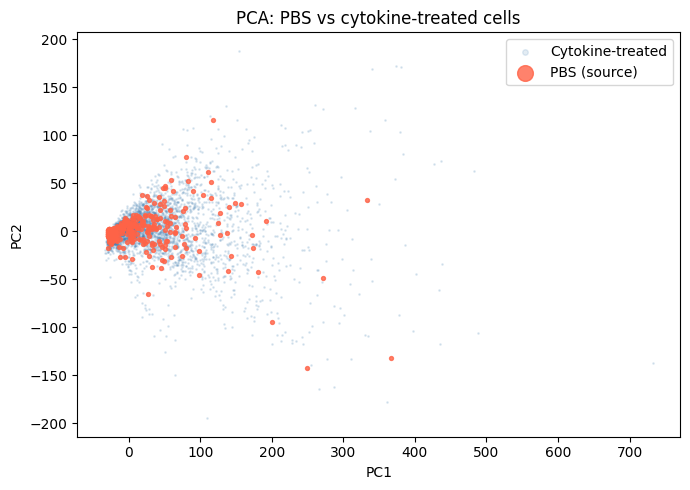

In [40]:
N_COMPONENTS = 50

X_dense = np.array(adata.X.todense()) if hasattr(adata.X, "todense") else np.array(adata.X)

pca = PCATransform(n_components=N_COMPONENTS)
adata.obsm["X_pca"] = pca.fit_transform(X_dense).astype(np.float32)
print(f"PCA done. Shape: {adata.obsm['X_pca'].shape}")

pbs_mask = adata.obs["treatment"].values == "PBS"
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    adata.obsm["X_pca"][~pbs_mask, 0],
    adata.obsm["X_pca"][~pbs_mask, 1],
    s=1,
    alpha=0.15,
    color="steelblue",
    label="Cytokine-treated",
)
ax.scatter(
    adata.obsm["X_pca"][pbs_mask, 0],
    adata.obsm["X_pca"][pbs_mask, 1],
    s=8,
    alpha=0.8,
    color="tomato",
    label="PBS (source)",
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA: PBS vs cytokine-treated cells")
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

## Section 3: SCFlow Register Setup

We pass the DataManager configuration directly to `register_adata`. Two new parameters compared to Tutorial 210:

- `sample_rep='X_pca'` — use 50-dim PCA coords as the state representation
- `conditions={'cytokine_level': ['cytokine']}` — condition covariate is `obs['cytokine']`
- `conditions_reps={'cytokine_level': 'esm2_embeddings'}` — look up ESM2 vectors from `adata.uns`
- `control_values_dict={'cytokine_level': 'PBS'}` — PBS cells are the source population
- `groups=['cell_type']` — **NEW**: outer stratification by cell type; each outer tree node groups cells of one cell type, and the source distribution for each leaf contains only PBS cells of that cell type
- `groups_encoding={'cell_type': 'label'}` — **NEW**: how to encode the group identity (integer label encoding)

In [41]:
SCFlow.register_adata(
    adata,
    sample_rep="X_pca",
    conditions={"cytokine_level": ["cytokine"]},
    conditions_reps={"cytokine_level": "esm2_embeddings"},
    control_values_dict={"cytokine_level": "PBS"},
    groups=["cell_type"],
    groups_encoding={"cell_type": "label"},
)

In [42]:
print("state_dim:             ", SCFlow._dims_registry.state_dim)
print("condition_reps_dims:   ", SCFlow._dims_registry.condition_reps_dims)
print("source_lin_dim:        ", SCFlow._dims_registry.source_lin_dim)
print("target_lin_dim:        ", SCFlow._dims_registry.target_lin_dim)

state_dim:              50
condition_reps_dims:    {'cytokine_level': 2560}
source_lin_dim:         50
target_lin_dim:         50


## Section 4: Exploring the Grouped Data Tree

When `groups=` is set, `compile_adata` produces a **three-level tree** instead of two:

```
NestedData (root)
 └── NestedData  key=('CD4 T',)           ← level 1: cell types
      └── MatchedData  key=('IFN-alpha2',) ← level 2: conditions (cytokines)
           ├── target_distribution  — IFN-alpha2-treated CD4 T cells
           └── source_distribution  — PBS CD4 T cells only
 └── NestedData  key=('CD8 T',)
      └── MatchedData  key=('IFN-alpha2',)
           └── source_distribution  — PBS CD8 T cells only   ← different source!
```

Each `MatchedData` leaf uses only the PBS cells **of that specific cell type** as its source.
This means the model never mixes cell types: source and target are always from the same cell type.

`flatten()` still gives all leaves at once — grouping is structural, not a training algorithm change.

In [43]:
# Compile the adata to inspect the grouped tree structure
# adata_sorted = model.dm.sort_adata(adata)
# tree = model.dm.compile_adata(adata_sorted)

# outer_keys = list(tree.mapping.keys())
# print(f"Outer level (cell types): {len(outer_keys)} groups")
# print("First 5:", outer_keys[:5])
# print()

# example_ct_key = outer_keys[0]
# inner_keys = list(tree[example_ct_key].mapping.keys())
# print(f"Inner level for {example_ct_key}: {len(inner_keys)} cytokines")
# print("First 5:", inner_keys[:5])
# print()

# all_leaves = list(tree.flatten())
# print(f"Total leaves: {len(all_leaves)}  (= {len(outer_keys)} cell types × ~{len(inner_keys)} cytokines)")

In [44]:
# Inspect one leaf — source cells are PBS cells of that specific cell type only
# example_ct_key  = list(tree.mapping.keys())[0]
# example_cyt_key = list(tree[example_ct_key].mapping.keys())[0]
# matched = tree[example_ct_key][example_cyt_key]

# print(f"Group (cell type) : {example_ct_key}")
# print(f"Condition (cytokine): {example_cyt_key}")
# print(f"Source cells (PBS of this cell type only): {matched.n_src_obs}")
# print(f"Target cells (cytokine-treated, same cell type): {matched.n_tgt_obs}")
# print()
# print("groups_data on target (contains the cell-type label encoding):")
# print("  ", matched.target_distribution.groups_data)

## Section 5: Model Setup

Now we create an SCFlow model instance. We keep it simple with only the essential parameters.

* `method_id` tells SCFlow what type of method to use. `cfm` — `ConditionalFlowMatching` — is the general flow matching algorithm provided in this package. The other option is `ffm`. If you want to use your own custom method for training, use `method_cls` instead.
* `backend` tells SCFlow whether to use `torch` or `jax`. Defaults to `torch` if not provided.

> **Note**: `method_cls` has higher priority than `method_id` if both are given.

In [45]:
model = SCFlow(
    method_id="cfm",
    backend="torch",
    condition_encoder_input_layers={
        "cytokine_level": {"output_dim": 256},
        "cell_type": {"output_dim": 256},
    },
    time_features_id="torch-cfm",
    vf_decoder_mlp_kwargs={"hidden_dims": [32, 32]},
)

In [46]:
print(f"Backend:         {model.backend}")
print(f"DataManager:     {model.dm}")
print(f"Method:          {model.method}")
print(f"Paired Settings: {model.is_paired_setting}")

Backend:         torch
DataManager:     <sc_flow.data._manager.DataManager object at 0x000001ABCBD58690>
Method:          <sc_flow.backends.torch.methods.library._cfm.CFM object at 0x000001ABC4C47530>
Paired Settings: True


## Section 6: Training

Training the model via the SCFlow instance is straightforward as shown here. It creates a `trainer` which holds all the logs for training and validation, accessible as a `pd.DataFrame`.

With grouping active, `model.train` sees **cell type × cytokine** leaves instead of just cytokine leaves. The batch sampler draws from all of them uniformly — no code change is needed.

In [ ]:
BATCH_SIZE = 256
adata = model.dm.sort_adata(adata)
model.train(
    adata,
    n_train_steps=1_000,
    train_batch_size=BATCH_SIZE,
    optim_kwargs={"lr": 1e-5},
    train_sampler_kwargs={"replace_samples": True},
)

  0%|          | 0/10000 [00:00<?, ?it/s]c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
  0%|          | 1/10000 [00:00<44:51,  3.71it/s]c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), f

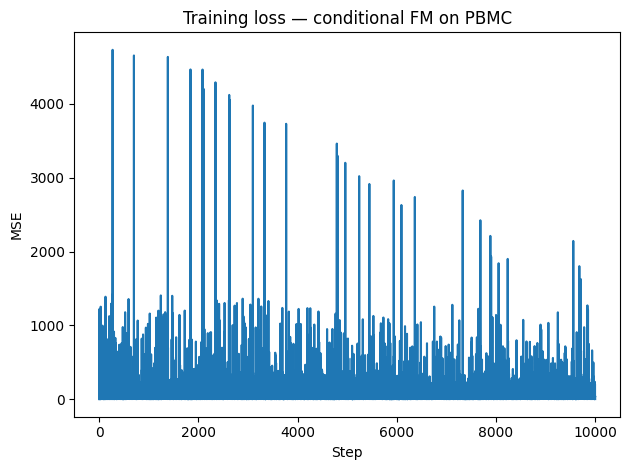

In [48]:
logs_df = model.trainer.get_train_logs_df()
plt.plot(logs_df.index, logs_df["loss"])
plt.title("Training loss — conditional FM on PBMC")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()

## Section 7: Saving & Loading Model

Before moving on to testing, let's save the model. SCFlow allows you to save the entire model along with the registered data.

In [49]:
model.save(filepath="cfm_pbmc_conditional_model.pt", allow_overwrite=True)

In [50]:
model = SCFlow.load(filepath="cfm_pbmc_conditional_model.pt")

## Section 8: Testing

We pass the full adata to `model.predict`. With grouping, the DataManager pairs PBS source cells **of each cell type** with cytokine target cells **of the same cell type**, producing one transport map per (cell type, cytokine) pair.

The returned AnnData has `obs['cytokine']` and `obs['cell_type']` so we can filter to any combination of interest.

In [51]:
CYTOKINES_TO_TEST = ["IFN-alpha2", "IL-2", "EGF", "CT-1"]
CYTOKINES_TO_TEST = [c for c in CYTOKINES_TO_TEST if c in usable_cytokines]
print("Testing:", CYTOKINES_TO_TEST)

adata_pred = model.predict(adata)
print(adata_pred)

Testing: ['IL-2', 'EGF', 'CT-1']


Predicting:   0%|          | 0/1149 [00:00<?, ?it/s]c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
Predicting:   0%|          | 1/1149 [00:00<05:02,  3.80it/s]c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
Predicting:   0%|          | 2/1149 [00:00<04:20,  4.40it/s]c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was pas

AnnData object with n_obs × n_vars = 49077 × 50
    obs: 'cell_type', 'cytokine'


C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\anndata\_core\anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


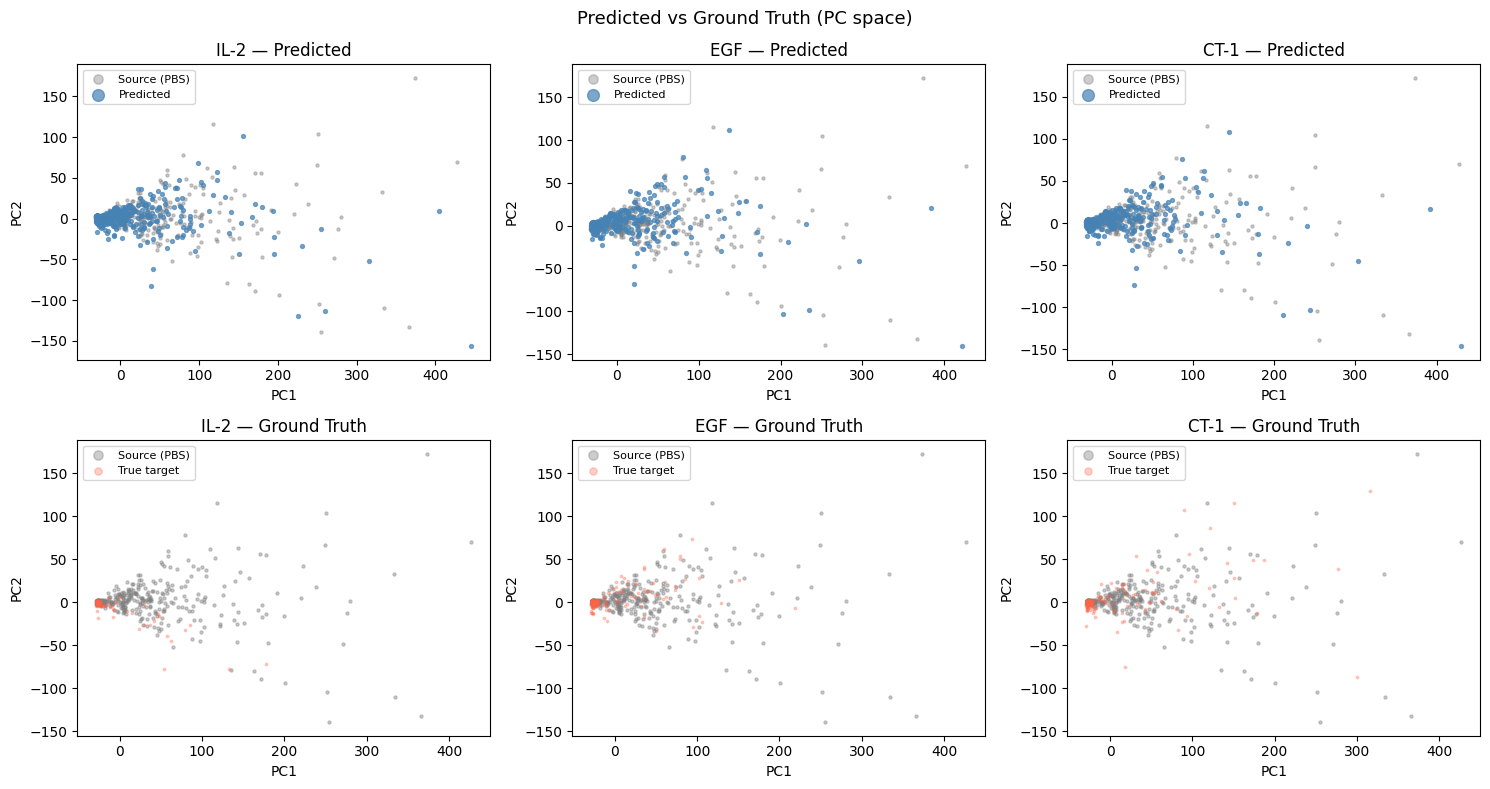

In [52]:
pbs_pca = adata.obsm["X_pca"][pbs_mask]

fig, axes = plt.subplots(2, len(CYTOKINES_TO_TEST), figsize=(5 * len(CYTOKINES_TO_TEST), 8))
if len(CYTOKINES_TO_TEST) == 1:
    axes = axes.reshape(2, 1)

for col, cyt in enumerate(CYTOKINES_TO_TEST):
    tgt_pca = adata.obsm["X_pca"][adata.obs["cytokine"].values == cyt]
    pred = np.array(adata_pred[adata_pred.obs["cytokine"] == cyt].X)

    axes[0, col].scatter(pbs_pca[:, 0], pbs_pca[:, 1], s=5, alpha=0.4, color="gray", label="Source (PBS)")
    axes[0, col].scatter(pred[:, 0], pred[:, 1], s=8, alpha=0.7, color="steelblue", label="Predicted")
    axes[0, col].set_title(f"{cyt} — Predicted")

    axes[1, col].scatter(pbs_pca[:, 0], pbs_pca[:, 1], s=5, alpha=0.4, color="gray", label="Source (PBS)")
    axes[1, col].scatter(tgt_pca[:, 0], tgt_pca[:, 1], s=3, alpha=0.3, color="tomato", label="True target")
    axes[1, col].set_title(f"{cyt} — Ground Truth")

    for row in range(2):
        axes[row, col].set_xlabel("PC1")
        axes[row, col].set_ylabel("PC2")
        axes[row, col].legend(markerscale=3, fontsize=8)

plt.suptitle("Predicted vs Ground Truth (PC space)", fontsize=13)
plt.tight_layout()
plt.show()

## Section 9: ODE Trajectories

We visualise how a small set of PBS source cells travel through PCA space from t=0 to t=1
under two different cytokine conditions.

Under different conditions the **same PBS starting cells** follow **different paths**,
arriving at different regions of PCA space — that is what the condition encoder has learned.

> **Note**: Plotting 50-dim trajectories in 2D is only an approximation of the true movement.

In [53]:
adata = model.dm.sort_adata(adata)

In [ ]:
CYT_A, CYT_B = CYTOKINES_TO_TEST[0], CYTOKINES_TO_TEST[1]
N_TRAJ = 30
CT = "CD4 Memory"  # pick one cell type with enough PBS cells

ct_pbs_pca = adata.obsm["X_pca"][(adata.obs["cell_type"] == CT) & (adata.obs["treatment"] == "PBS")]
src_sub = ct_pbs_pca[:N_TRAJ]


def make_traj_adata(cyt, src):
    """Construct an adata with the same source cells (PBS of the chosen cell type) but target cells from the specified cytokine."""
    tgt = adata.obsm["X_pca"][(adata.obs["cell_type"] == CT) & (adata.obs["cytokine"] == cyt)][: len(src)]
    a = ad.AnnData(
        obs=pd.DataFrame(
            {
                "cytokine": ["PBS"] * len(src) + [cyt] * len(tgt),
                "cell_type": [CT] * (len(src) + len(tgt)),
            }
        )
    )
    a.obsm["X_pca"] = np.vstack([src, tgt]).astype(np.float32)
    a.uns["esm2_embeddings"] = adata.uns["esm2_embeddings"]
    return model.dm.sort_adata(a)


adata_traj_a = model.predict(make_traj_adata(CYT_A, src_sub), return_trajectory=True, num_steps=20)
adata_traj_b = model.predict(make_traj_adata(CYT_B, src_sub), return_trajectory=True, num_steps=20)

traj_a = adata_traj_a.obsm["trajectory"]
traj_b = adata_traj_b.obsm["trajectory"]
print(f"trajectory A shape: {traj_a.shape}")
print(f"trajectory B shape: {traj_b.shape}")

C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Predicting:   0%|          | 0/1 [00:00<?, ?it/s]c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
Predicting: 100%|██████████| 1/1 [00:00<00:00, 22.51it/s]
C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\functools.

trajectory A shape: (30, 20, 50)
trajectory B shape: (30, 20, 50)



C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


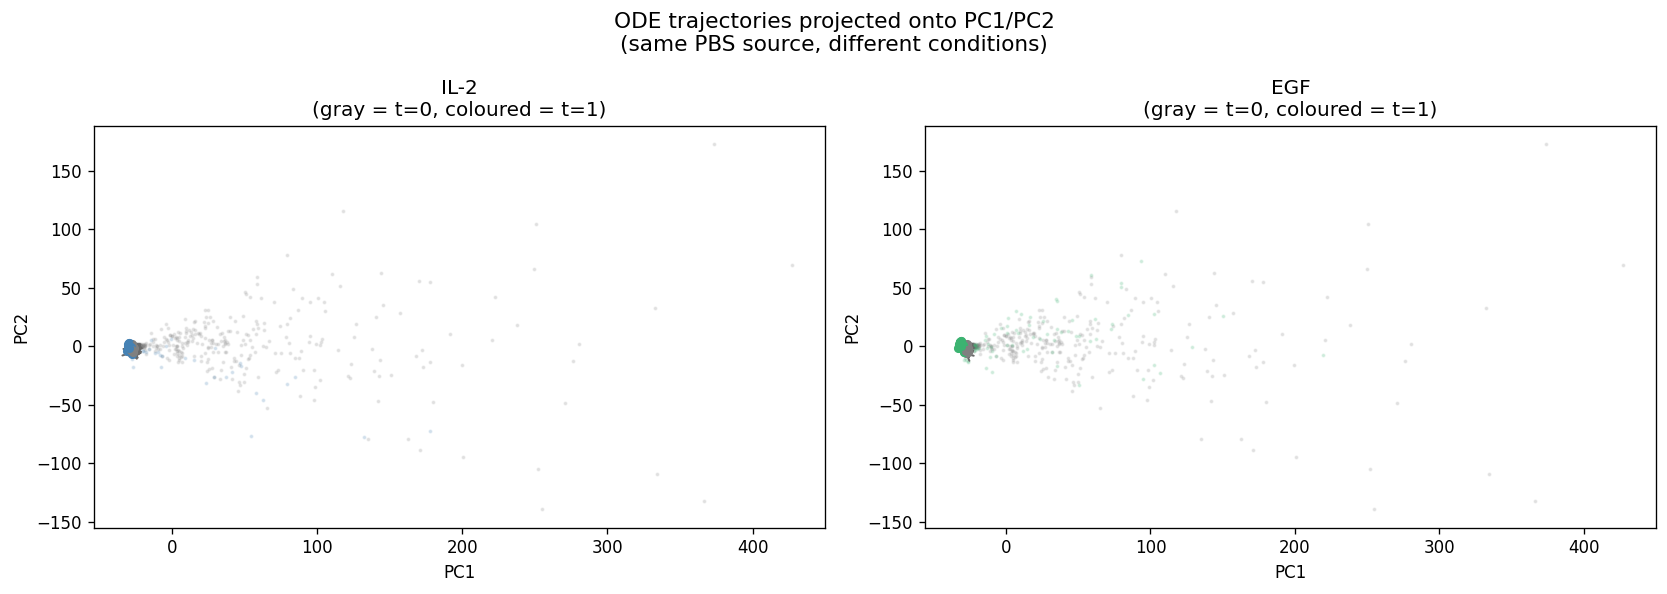

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

for ax, traj, cyt, tgt_color in [
    (axes[0], traj_a, CYT_A, "steelblue"),
    (axes[1], traj_b, CYT_B, "mediumseagreen"),
]:
    tgt_pca = adata.obsm["X_pca"][adata.obs["cytokine"].values == cyt]

    ax.scatter(pbs_pca[:, 0], pbs_pca[:, 1], s=2, alpha=0.15, color="gray")
    ax.scatter(tgt_pca[:, 0], tgt_pca[:, 1], s=2, alpha=0.15, color=tgt_color)

    mid = traj.shape[1] // 2
    n = traj.shape[0]
    for i in range(n):
        ax.plot(traj[i, :, 0], traj[i, :, 1], lw=0.8, alpha=0.6, color="dimgray")
        ax.annotate(
            "",
            xy=(traj[i, mid + 1, 0], traj[i, mid + 1, 1]),
            xytext=(traj[i, mid, 0], traj[i, mid, 1]),
            arrowprops={"arrowstyle": "->", "color": "dimgray", "lw": 1.2},
        )
        ax.scatter(traj[i, 0, 0], traj[i, 0, 1], s=20, color="gray", zorder=5)
        ax.scatter(traj[i, -1, 0], traj[i, -1, 1], s=20, color=tgt_color, zorder=5)

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"{cyt}\n(gray = t=0, coloured = t=1)")

plt.suptitle("ODE trajectories projected onto PC1/PC2\n(same PBS source, different conditions)", fontsize=13)
plt.tight_layout()
plt.show()

### What's next?

| Tutorial | What it introduces |
|---|---|
| [`300_genot_pancreas.ipynb`](300_genot_pancreas.ipynb) | GENOT: unbalanced optimal transport for single-cell data |